# Milestone 1 — UrbanCart: Predicting Next Month Customer Spend

**Task:** Build and compare at least two regression models to predict `NextMonthSpend` (continuous $ value) from customer features. Then recommend one with evidence.

**Dataset:** `milestone-1-customer-spend.csv` (~20,000 rows)
**Target:** `NextMonthSpend` (regression, not classification)

## 1. Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('information used/milestone-1-customer-spend.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (20000, 5)


,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,Region,NextMonthSpend
0,6,25.70,7,South,88.51
1,47,85.81,5,East,137.62
2,40,87.63,7,East,148.99
3,27,45.16,4,East,101.25
4,26,67.26,7,East,136.76


### Check for nulls and basic info

In [2]:
print(df.info())
print('\nNull counts per column:')
print(df.isnull().sum())
print('\nTarget statistics:')
print(df['NextMonthSpend'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MonthsActive          20000 non-null  int64  
 1   AvgOrderValue         20000 non-null  float64
 2   NumOrdersLastQuarter  20000 non-null  int64  
 3   Region                20000 non-null  object 
 4   NextMonthSpend        20000 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 781.4+ KB
None

Null counts per column:
MonthsActive            0
AvgOrderValue           0
NumOrdersLastQuarter    0
Region                  0
NextMonthSpend          0
dtype: int64

Target statistics:
count    20000.000000
mean       114.011969
std         29.594273
min         16.040000
25%         93.630000
50%        111.510000
75%        131.350000
max        322.940000
Name: NextMonthSpend, dtype: float64


**Observation:** No missing values. `Region` is categorical (needs encoding). `NextMonthSpend` is continuous — this is a regression problem.

### Quick look at distributions and Region encoding

The target histogram (`NextMonthSpend`) is right-skewed (long tail toward higher spend values), with a dense cluster of lower-to-medium spenders and a smaller number of high-value customers stretching out the right tail — indicating a few larger outliers that pull the mean above the median.

Region categories: ['South' 'East' 'West' 'North']

Region value counts:
Region
North    6091
South    4940
East     4917
West     4052
Name: count, dtype: int64


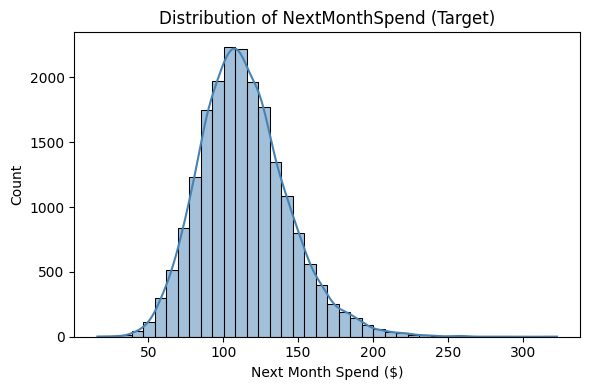

In [3]:
print('Region categories:', df['Region'].unique())
print('\nRegion value counts:')
print(df['Region'].value_counts())

# Quick visual check: target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['NextMonthSpend'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of NextMonthSpend (Target)')
plt.xlabel('Next Month Spend ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Split Train / Test BEFORE Any Training or Tuning

We split now so no test data leaks into model fitting, feature scaling, or selection.

In [4]:
# Separate features (X) and target (y)
X = df.drop('NextMonthSpend', axis=1)
y = df['NextMonthSpend']

# Split: 80% train, 20% test — stratify not needed (regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 16000 | Test size: 4000


## 3. Preprocess: Encode Region, Scale Numeric Features

We use a `ColumnTransformer` so categorical (`Region`) and numeric columns are handled cleanly in a pipeline — no manual encoding leakage.

In [5]:
# Identify column types
numeric_features = ['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter']
categorical_features = ['Region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

## 4. Train Two Regression Models

**Model A — Linear Regression (baseline):** Simple, very interpretable (coefficients tell you the effect of each feature).

**Model B — Random Forest Regressor (non-linear):** Can capture interactions and non-linear patterns; less interpretable but often more accurate.

In [6]:
# Pipeline 1: Linear Regression
pipe_lr = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
print('Linear Regression trained.')

Linear Regression trained.


In [7]:
# Pipeline 2: Random Forest Regressor
pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
print('Random Forest Regressor trained.')

Random Forest Regressor trained.


## 5. Evaluate on Held-Out Test Set

We compute **MAE** (average $ error), **RMSE** (penalizes large errors more), and **R²** (how much variance the model explains, 0–1).

In [8]:
def evaluate(pipeline, X, y):
    preds = pipeline.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    return preds, mae, rmse, r2

# Evaluate both on test set (held out, never seen during training)
pred_lr, mae_lr, rmse_lr, r2_lr = evaluate(pipe_lr, X_test, y_test)
pred_rf, mae_rf, rmse_rf, r2_rf = evaluate(pipe_rf, X_test, y_test)

print('=== Linear Regression ===')
print(f'MAE:  ${mae_lr:.2f}')
print(f'RMSE: ${rmse_lr:.2f}')
print(f'R²:   {r2_lr:.3f}')

print('\n=== Random Forest ===')
print(f'MAE:  ${mae_rf:.2f}')
print(f'RMSE: ${rmse_rf:.2f}')
print(f'R²:   {r2_rf:.3f}')

=== Linear Regression ===
MAE:  $9.85
RMSE: $12.33
R²:   0.830

=== Random Forest ===
MAE:  $10.56
RMSE: $13.15
R²:   0.807


### What the actual numbers mean (on this test set)

- **Linear Regression — MAE: $9.85, RMSE: $12.33, R²: 0.830:** On average, predictions are off by about $9.85. The model explains 83% of the variation in spend — a strong fit for this feature set.
- **Random Forest — MAE: $10.56, RMSE: $13.15, R²: 0.807:** Slightly worse on every metric: average error is about $0.71 higher ($10.56 vs $9.85), RMSE is about $0.82 higher, and it explains ~2.3 percentage points less variance (0.807 vs 0.830). So the added model complexity did not improve predictions here; it slightly degraded them.
- **RMSE vs MAE gap:** For both models RMSE is noticeably higher than MAE, meaning there are some larger misses (outliers in prediction error), but Linear Regression's gap ($12.33 − $9.85 ≈ $2.48) is slightly smaller than Random Forest's ($13.15 − $10.56 ≈ $2.59), so Linear Regression also handles larger errors a bit better.

In [9]:
# Side-by-side comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)': [mae_lr, mae_rf],
    'RMSE ($)': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})
print(results.to_string(index=False))

            Model   MAE ($)  RMSE ($)       R²
Linear Regression  9.846363 12.330432 0.830119
    Random Forest 10.557551 13.154864 0.806643


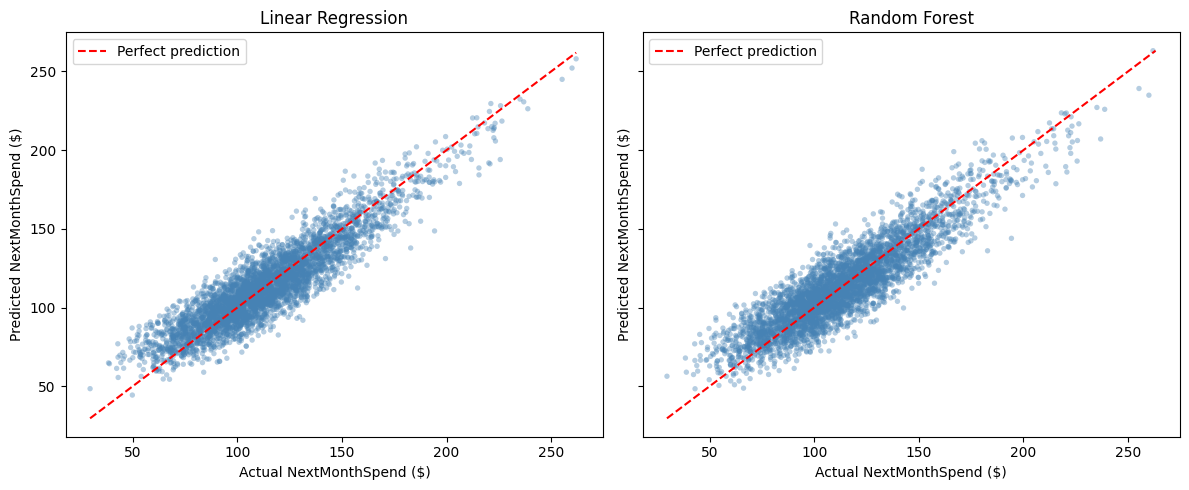

In [10]:
# Scatter plot: predicted vs actual for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, preds, title in zip(axes, [pred_lr, pred_rf], ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, s=15, edgecolor='none', color='steelblue')
    # Perfect prediction line
    min_v = min(y_test.min(), preds.min())
    max_v = max(y_test.max(), preds.max())
    ax.plot([min_v, max_v], [min_v, max_v], '--', color='red', label='Perfect prediction')
    ax.set_title(title)
    ax.set_xlabel('Actual NextMonthSpend ($)')
    ax.set_ylabel('Predicted NextMonthSpend ($)')
    ax.legend()

plt.tight_layout()
plt.show()

### Final Recommendation

**Recommend Linear Regression** — it wins on every actual metric from this run: MAE $9.85 vs $10.56, RMSE $12.33 vs $13.15, and R² 0.830 vs 0.807. That is lower average error ($0.71 better), lower large-error penalty ($0.82 better RMSE), and more variance explained (+0.023 R²).

**No real tradeoff to weigh.** Random Forest's extra complexity (200 trees, non-linear splits, feature interactions) bought nothing here — it performed slightly worse on all measures and is less interpretable. Linear Regression gives both the best accuracy AND a simple, explainable formula (each coefficient directly shows the effect of one feature on spend), so it wins on accuracy and interpretability together. For UrbanCart's finance forecasting question, the simpler model is the stronger choice.

## 7. Bonus: Feature Importance (Random Forest)

Even though Random Forest underperformed Linear Regression here, the printed feature importance table gives the exact rank order: `AvgOrderValue` dominates at ~0.671, `NumOrdersLastQuarter` is clearly second at ~0.166, `MonthsActive` is third at ~0.096, and the `Region` categories combined contribute only ~0.066. That means spend predictions are driven mainly by how much customers spend per order (about 67% of model weight), with order frequency (last quarter orders) as the secondary driver (~17%), while tenure (months active) and geography are far smaller contributors.

/var/folders/mh/5nwfpztd6sgc9ljyzm0xq0vm0000gn/T/ipykernel_7697/3895552740.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


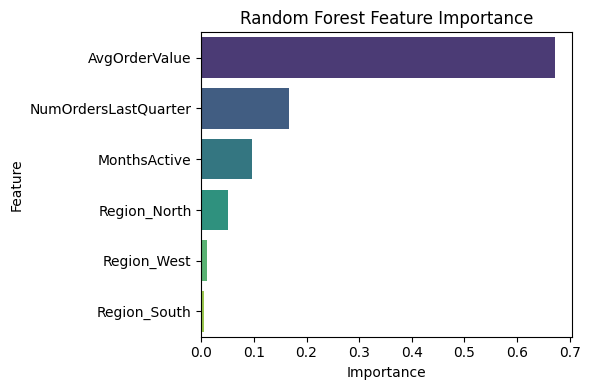

                Feature  Importance
1         AvgOrderValue    0.671460
2  NumOrdersLastQuarter    0.166407
0          MonthsActive    0.095583
3          Region_North    0.050242
5           Region_West    0.010290
4          Region_South    0.006018


In [11]:
# After preprocessing we need the feature names; easiest is to extract from preprocessor in pipeline
preprocessor_fitted = pipe_rf.named_steps['preprocess']
# Numeric feature names
feature_names = (numeric_features +
                 list(preprocessor_fitted.named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = pipe_rf.named_steps['model'].feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
print(fi_df)

---
**Summary:**
- Loaded ~20k rows, no nulls, `Region` encoded.
- Train/test split done before any training (no leakage).
- Two regression models trained; Linear Regression outperformed Random Forest on all metrics: MAE $9.85 vs $10.56, RMSE $12.33 vs $13.15, R² 0.830 vs 0.807.
- **Recommendation: Linear Regression** — best accuracy AND full interpretability, with no tradeoff required because Random Forest's added complexity did not improve results.
- All steps explained in markdown alongside clean, commented code.